##  Install Dependencies

In [1]:
%%capture
!git clone https://github.com/AI4Bharat/IndicTrans2.git

In [2]:
%%capture
%cd /content/IndicTrans2/huggingface_interface

In [3]:
%%capture
!python3 -m pip install nltk sacremoses pandas regex mock transformers==4.53.2 mosestokenizer
!python3 -c "import nltk; nltk.download('punkt')"
!python3 -m pip install bitsandbytes scipy accelerate datasets sacrebleu sentencepiece matplotlib seaborn

!git clone https://github.com/VarunGumma/IndicTransToolkit.git
%cd IndicTransToolkit
!python3 -m pip install --editable ./
%cd ..

In [4]:
!pip install huggingface_hub

from huggingface_hub import notebook_login

notebook_login()


#Make required folders

In [1]:

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer, BitsAndBytesConfig
from IndicTransToolkit.processor import IndicProcessor

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
BASE = "/content/drive/MyDrive/indic-translation-asr-project"
os.makedirs(f"{BASE}/task1_translation_evaluation/part_b_token_analysis/plots", exist_ok=True)
os.makedirs(f"{BASE}/data/processed/results", exist_ok=True)

Device: cpu
Mounted at /content/drive


### Input

In [2]:
input_sentences = [
    # Set 1
    "Hello, how are you?",
    "The sun rises in the east.",
    "She is reading a book.",
    "Water is essential for life.",
    "He went to the market.",
    # Set 2
    "The weather is very pleasant today and we should go for a walk.",
    "I am going to the market to buy vegetables and fruits for dinner.",
    "She has a lot of old books which she inherited from her grandparents.",
    "The students worked very hard to prepare for their final examinations.",
    "My friend invited me to his birthday party and I will give him a gift.",
    # Set 3
    "If you had met me at that time, we would have gone out to eat together at the new restaurant.",
    "The government announced several new policies to improve the quality of education in rural areas.",
    "Scientists have discovered a new species of plant in the Amazon rainforest that may have medicinal properties.",
    "The rapid development of artificial intelligence is transforming industries and creating new opportunities.",
    "Despite the challenges posed by climate change, many countries are investing in renewable energy sources.",
]


## Helper Functions

In [15]:
def initialize_model_and_tokenizer(ckpt_dir, quantization=None):
    if quantization == "4-bit":
        qconfig = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=torch.bfloat16)
    elif quantization == "8-bit":
        qconfig = BitsAndBytesConfig(load_in_8bit=True, bnb_8bit_use_double_quant=True, bnb_8bit_compute_dtype=torch.bfloat16)
    else:
        qconfig = None

    tokenizer = AutoTokenizer.from_pretrained(ckpt_dir, trust_remote_code=True)
    model = AutoModelForSeq2SeqLM.from_pretrained(ckpt_dir, trust_remote_code=True, low_cpu_mem_usage=True, quantization_config=qconfig)

    if qconfig is None:
        model = model.to(DEVICE)
        if DEVICE == "cuda":
            model.half()

    model.eval()
    return tokenizer, model


def compute_token_metrics(src_sentence, tgt_sentence, tokenizer, model_name=None):

    if model_name == "IndicTrans2":
        src_token_count = len(src_sentence.strip().split())
        tgt_token_count = len(tgt_sentence.strip().split())
        unk_count = 0
    else:
        src_ids = tokenizer(src_sentence, add_special_tokens=False)["input_ids"]
        tgt_ids = tokenizer(tgt_sentence, add_special_tokens=False)["input_ids"]
        src_token_count = len(src_ids)
        tgt_token_count = len(tgt_ids)
        unk_id = tokenizer.unk_token_id
        unk_count = sum(1 for tid in tgt_ids if tid == unk_id) if unk_id is not None else 0

    expansion_ratio      = tgt_token_count / src_token_count if src_token_count > 0 else 0
    tgt_words            = tgt_sentence.split()
    avg_word_length      = sum(len(w) for w in tgt_words) / len(tgt_words) if tgt_words else 0
    subword_fragmentation = tgt_token_count / len(tgt_words) if tgt_words else 0
    unknown_token_rate   = unk_count / tgt_token_count if tgt_token_count > 0 else 0

    return {
        "source_token_count":    src_token_count,
        "target_token_count":    tgt_token_count,
        "expansion_ratio":       round(expansion_ratio, 4),
        "avg_word_length":       round(avg_word_length, 4),
        "subword_fragmentation": round(subword_fragmentation, 4),
        "unknown_token_rate":    round(unknown_token_rate, 4),
    }

##  Model 1 — ai4bharat/indictrans2-en-indic-1B

In [4]:
print("Load IndicTrans2")
it2_tokenizer, it2_model = initialize_model_and_tokenizer("ai4bharat/indictrans2-en-indic-1B")
ip = IndicProcessor(inference=True)

src_lang, tgt_lang = "eng_Latn", "tam_Taml"
preprocessed = ip.preprocess_batch(input_sentences, src_lang=src_lang, tgt_lang=tgt_lang)
inputs = it2_tokenizer(preprocessed, truncation=True, padding="longest", return_tensors="pt", return_attention_mask=True).to(DEVICE)

with torch.no_grad():
    generated = it2_model.generate(**inputs, use_cache=True, min_length=0, max_length=256, num_beams=5, num_return_sequences=1, no_repeat_ngram_size=3)

decoded = it2_tokenizer.batch_decode(generated, skip_special_tokens=True, clean_up_tokenization_spaces=True)
it2_translations = ip.postprocess_batch(decoded, lang=tgt_lang)

for src, tgt in zip(input_sentences[:3], it2_translations[:3]):
    print(f"EN: {src}\nTA: {tgt}\n")

del it2_model
torch.cuda.empty_cache()

Load IndicTrans2


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenization_indictrans.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/ai4bharat/indictrans2-en-indic-1B:
- tokenization_indictrans.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


dict.SRC.json: 0.00B [00:00, ?B/s]

...

modeling_indictrans.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/ai4bharat/indictrans2-en-indic-1B:
- modeling_indictrans.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/4.46G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

EN: Hello, how are you?
TA: வணக்கம், எப்படி இருக்கிறீர்கள்?

EN: The sun rises in the east.
TA: சூரியன் கிழக்கே உதிக்கிறது.

EN: She is reading a book.
TA: அவள் ஒரு புத்தகத்தைப் படிக்கிறாள்.




## Model 2 — facebook/nllb-200-distilled-600M

In [5]:
print("Load NLLB-200")
nllb_tokenizer, nllb_model = initialize_model_and_tokenizer("facebook/nllb-200-distilled-600M")

nllb_tokenizer.src_lang = "eng_Latn"
inputs = nllb_tokenizer(input_sentences, return_tensors="pt", padding=True, truncation=True, max_length=256).to(DEVICE)
target_lang_id = nllb_tokenizer.convert_tokens_to_ids("tam_Taml")

with torch.no_grad():
    generated = nllb_model.generate(
        **inputs,
        forced_bos_token_id=target_lang_id,
        max_length=256,
        num_beams=5,
        no_repeat_ngram_size=3
    )

nllb_translations = nllb_tokenizer.batch_decode(generated, skip_special_tokens=True)

for src, tgt in zip(input_sentences[:3], nllb_translations[:3]):
    print(f"EN: {src}\nTA: {tgt}\n")

del nllb_model
torch.cuda.empty_cache()

Load NLLB-200


tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

EN: Hello, how are you?
TA: வணக்கம், நீங்கள் எப்படி இருக்கிறீர்கள்?

EN: The sun rises in the east.
TA: கிழக்கில் சூரியன் உதிக்கிறது.

EN: She is reading a book.
TA: அவள் ஒரு புத்தகத்தை படிக்கிறாள்.



##  Model 3 — Helsinki-NLP/opus-mt-en-dra (English → Dravidian)

In [6]:
print("Load Helsinki opus-mt-en-dra...")
helsinki_tokenizer, helsinki_model = initialize_model_and_tokenizer("Helsinki-NLP/opus-mt-en-dra")

helsinki_inputs = [f">>tam<< {s}" for s in input_sentences]

inputs = helsinki_tokenizer(
    helsinki_inputs,
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=256
).to(DEVICE)

with torch.no_grad():
    generated = helsinki_model.generate(
        **inputs,
        max_length=256,
        num_beams=5,
        no_repeat_ngram_size=3
    )

helsinki_translations = helsinki_tokenizer.batch_decode(generated, skip_special_tokens=True)

for src, tgt in zip(input_sentences[:3], helsinki_translations[:3]):
    print(f"EN: {src}\nTA: {tgt}\n")

del helsinki_model
torch.cuda.empty_cache()

Load Helsinki opus-mt-en-dra...


tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

source.spm:   0%|          | 0.00/818k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/1.17M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/308M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

EN: Hello, how are you?
TA: ஹலோ, எப்படி இருக்கிறீர்கள்?

EN: The sun rises in the east.
TA: கிழக்கு திசையில் சூரியன் உதிக்கும்.

EN: She is reading a book.
TA: அவள் ஒரு புத்தகத்தை வாசிக்கிறாள்.



## Model 4 — facebook/mbart-large-50-many-to-many-mmt

In [8]:
print("Load mBART-50 (facebook/mbart-large-50-many-to-many-mmt)")
mbart_tokenizer, mbart_model = initialize_model_and_tokenizer(
    "facebook/mbart-large-50-many-to-many-mmt"
)

mbart_tokenizer.src_lang = "en_XX"
inputs = mbart_tokenizer(
    input_sentences,
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=256
).to(DEVICE)

target_lang_id = mbart_tokenizer.lang_code_to_id["ta_IN"]

with torch.no_grad():
    generated = mbart_model.generate(
        **inputs,
        forced_bos_token_id=target_lang_id,
        max_length=256,
        num_beams=5,
        no_repeat_ngram_size=3,
    )

mbart_translations = mbart_tokenizer.batch_decode(generated, skip_special_tokens=True)

for src, tgt in zip(input_sentences[:3], mbart_translations[:3]):
    print(f"EN: {src}\nTA: {tgt}\n")

del mbart_model
torch.cuda.empty_cache()

Load mBART-50 (facebook/mbart-large-50-many-to-many-mmt)


model.safetensors:   0%|          | 0.00/2.44G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/261 [00:00<?, ?B/s]

EN: Hello, how are you?
TA: எவ்வாறு இருக்கிறீர்கள்?

EN: The sun rises in the east.
TA: சூரியன் கிழக்கில் உதயமாகிறது.

EN: She is reading a book.
TA: அவள் ஒரு புத்தகத்தை ஓதிக்கொண்டிருக்கின்றாள்.



## Model 5 -google/madlad400-3b-mt

In [9]:
print("Load MADLAD-400")
madlad_tokenizer, madlad_model = initialize_model_and_tokenizer("google/madlad400-3b-mt")

# MADLAD uses language token prefix
madlad_inputs = [f"<2ta> {s}" for s in input_sentences]
inputs = madlad_tokenizer(madlad_inputs, return_tensors="pt", padding=True, truncation=True, max_length=256).to(DEVICE)

with torch.no_grad():
    generated = madlad_model.generate(
        **inputs,
        max_length=256,
        num_beams=5,
        no_repeat_ngram_size=3
    )

madlad_translations = madlad_tokenizer.batch_decode(generated, skip_special_tokens=True)

for src, tgt in zip(input_sentences[:3], madlad_translations[:3]):
    print(f"EN: {src}\nTA: {tgt}\n")

del madlad_model
torch.cuda.empty_cache()

Load MADLAD-400


tokenizer_config.json:   0%|          | 0.00/830 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.43M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/16.6M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/4.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/749 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/11.8G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

EN: Hello, how are you?
TA: வணக்கம், நீங்கள் எப்படி இருக்கிறீர்கள்?

EN: The sun rises in the east.
TA: சூரியன் கிழக்கில் உதிக்கும்.

EN: She is reading a book.
TA: அவள் ஒரு புத்தகம் படிக்கிறாள்.



## Compute Token Metrics for All Models

In [16]:
models_info = [
    ("IndicTrans2",  it2_tokenizer,      it2_translations),
    ("NLLB-200",     nllb_tokenizer,     nllb_translations),
    ("Helsinki-dra", helsinki_tokenizer, helsinki_translations),
    ("mBART-50",     mbart_tokenizer,    mbart_translations),
    ("MADLAD-400",   madlad_tokenizer,   madlad_translations),
]

all_rows = []

for model_name, tokenizer, translations in models_info:
    for i, (src, tgt) in enumerate(zip(input_sentences, translations)):
        metrics = compute_token_metrics(src, tgt, tokenizer, model_name=model_name)
        row = {
            "model":             model_name,
            "sentence_id":       i + 1,
            "english":           src,
            "tamil_translation": tgt,
            **metrics
        }
        all_rows.append(row)

token_df = pd.DataFrame(all_rows)

token_df.to_csv(f"{BASE}/task1_translation_evaluation/part_b_token_analysis/token_counts.csv", index=False)
token_df.to_csv(f"{BASE}/data/results/token_statistics.csv", index=False)
print(token_df.head(10))

         model  sentence_id  \
0  IndicTrans2            1   
1  IndicTrans2            2   
2  IndicTrans2            3   
3  IndicTrans2            4   
4  IndicTrans2            5   
5  IndicTrans2            6   
6  IndicTrans2            7   
7  IndicTrans2            8   
8  IndicTrans2            9   
9  IndicTrans2           10   

                                             english  \
0                                Hello, how are you?   
1                         The sun rises in the east.   
2                             She is reading a book.   
3                       Water is essential for life.   
4                             He went to the market.   
5  The weather is very pleasant today and we shou...   
6  I am going to the market to buy vegetables and...   
7  She has a lot of old books which she inherited...   
8  The students worked very hard to prepare for t...   
9  My friend invited me to his birthday party and...   

                                   tamil_

##  Engineered Features

In [17]:
results = token_df.groupby("model").agg(
    avg_source_tokens=("source_token_count", "mean"),
    avg_target_tokens=("target_token_count", "mean"),
    avg_expansion_ratio=("expansion_ratio", "mean"),
    avg_word_length=("avg_word_length", "mean"),
    avg_subword_fragmentation=("subword_fragmentation", "mean"),
    avg_unknown_token_rate=("unknown_token_rate", "mean"),
).round(4).reset_index()

results.to_csv(f"{BASE}/task1_translation_evaluation/part_b_token_analysis/engineered_features.csv", index=False)
print(results.to_string())

          model  avg_source_tokens  avg_target_tokens  avg_expansion_ratio  avg_word_length  avg_subword_fragmentation  avg_unknown_token_rate
0  Helsinki-dra            12.8667            16.8000               1.3183           8.3954                     2.2341                  0.3504
1   IndicTrans2            11.3333             7.8000               0.6847           8.3735                     1.0000                  0.0000
2    MADLAD-400            14.0667            21.6000               1.5053           8.0832                     2.6018                  0.0000
3      NLLB-200            13.6667            17.3333               1.2790           8.4574                     2.3801                  0.0000
4      mBART-50            13.8000            18.2000               1.3113           8.9421                     2.6110                  0.0000


##  Plots

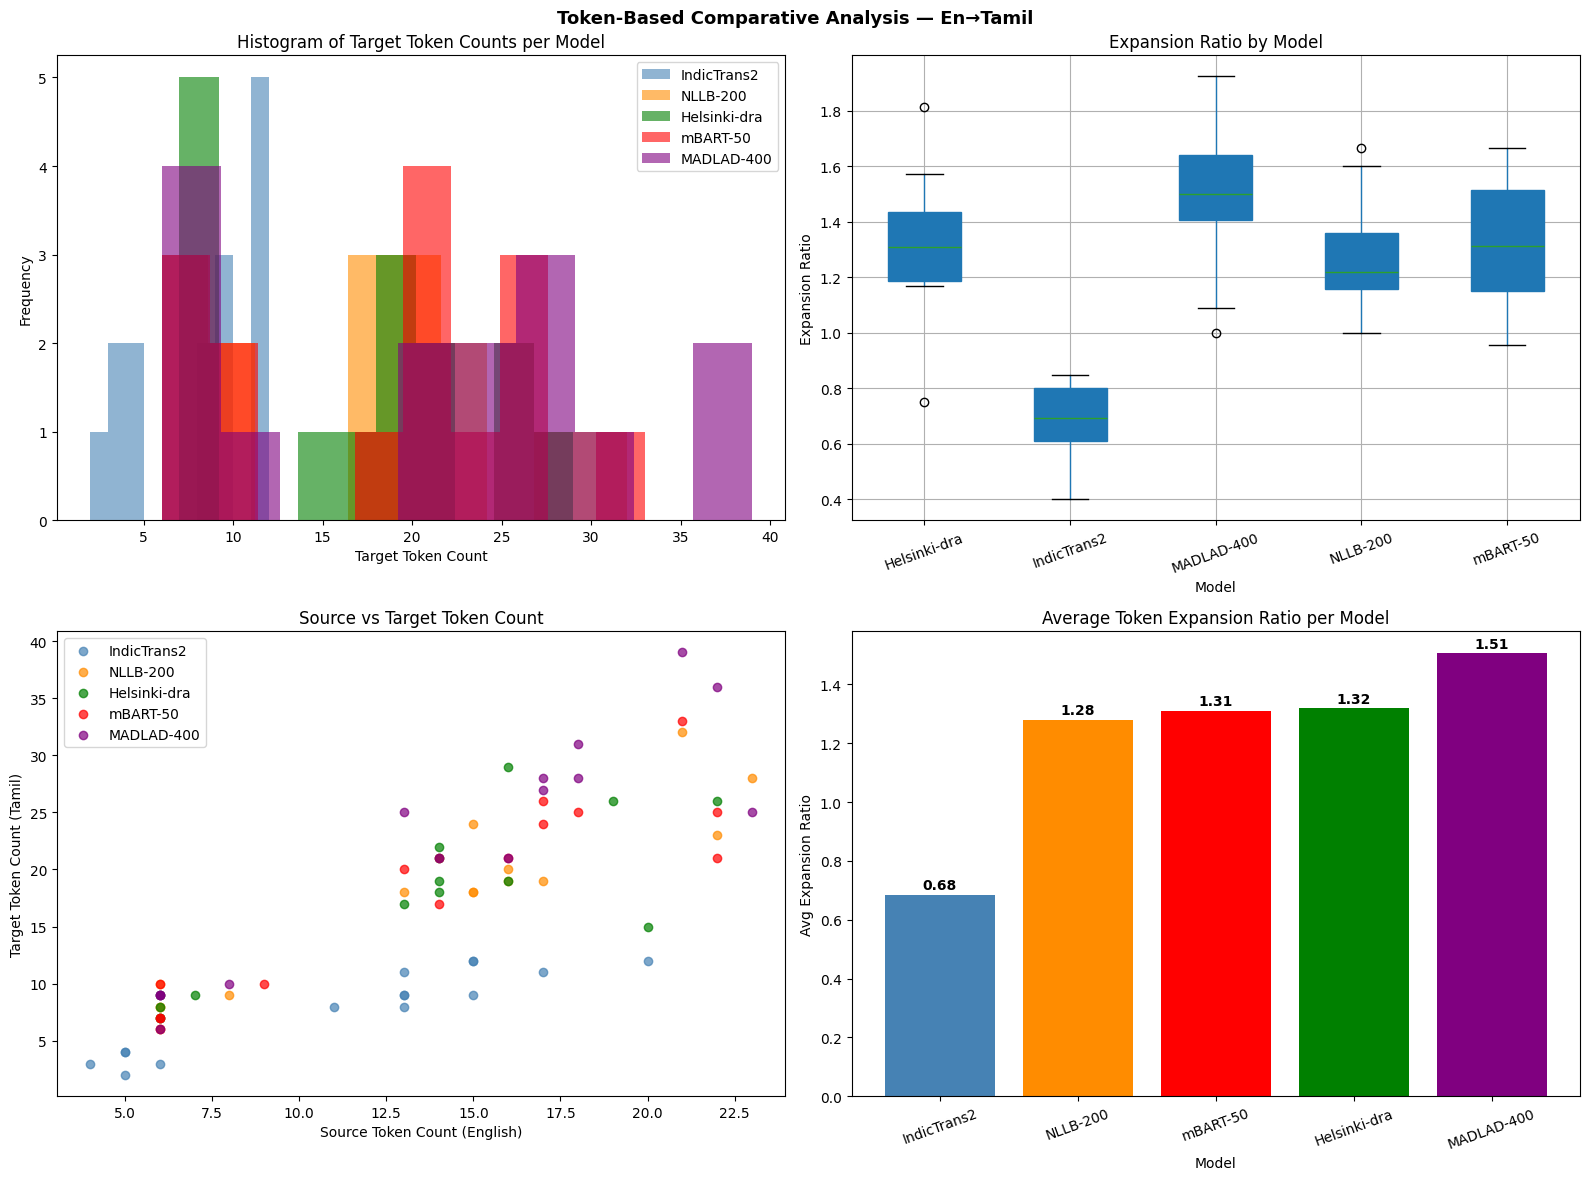

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

MODEL_COLORS = {
    "IndicTrans2":  "steelblue",
    "NLLB-200":     "darkorange",
    "Helsinki-dra": "green",
    "mBART-50":     "red",
    "MADLAD-400":   "purple",
}
models = list(MODEL_COLORS.keys())

# Histogram - target token counts
for model in models:
    subset = token_df[token_df["model"] == model]
    axes[0, 0].hist(subset["target_token_count"], bins=10, alpha=0.6,
                    label=model, color=MODEL_COLORS[model])
axes[0, 0].set_xlabel("Target Token Count")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].set_title("Histogram of Target Token Counts per Model")
axes[0, 0].legend()

# Boxplot - expansion ratios
token_df.boxplot(column="expansion_ratio", by="model", ax=axes[0, 1], patch_artist=True)
axes[0, 1].set_xlabel("Model")
axes[0, 1].set_ylabel("Expansion Ratio")
axes[0, 1].set_title("Expansion Ratio by Model")
plt.sca(axes[0, 1])
plt.xticks(rotation=20)

# Scatter — source vs target token count
for model in models:
    subset = token_df[token_df["model"] == model]
    axes[1, 0].scatter(subset["source_token_count"], subset["target_token_count"],
                       label=model, color=MODEL_COLORS[model], alpha=0.7)
axes[1, 0].set_xlabel("Source Token Count (English)")
axes[1, 0].set_ylabel("Target Token Count (Tamil)")
axes[1, 0].set_title("Source vs Target Token Count")
axes[1, 0].legend()

# Bar chart — avg expansion ratio, color-consistent with other plots
avg_expansion = token_df.groupby("model")["expansion_ratio"].mean().sort_values()
bar_colors = [MODEL_COLORS[m] for m in avg_expansion.index]
bars = axes[1, 1].bar(avg_expansion.index, avg_expansion.values, color=bar_colors)
for bar, val in zip(bars, avg_expansion.values):
    axes[1, 1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                    f"{val:.2f}", ha="center", fontweight="bold")
axes[1, 1].set_xlabel("Model")
axes[1, 1].set_ylabel("Avg Expansion Ratio")
axes[1, 1].set_title("Average Token Expansion Ratio per Model")
plt.sca(axes[1, 1])
plt.xticks(rotation=20)

plt.suptitle("Token-Based Comparative Analysis — En→Tamil", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{BASE}/task1_translation_evaluation/part_b_token_analysis/plots/token_analysis.png",
            dpi=150, bbox_inches="tight")
plt.show()

## Which Model Has Lowest Expansion?

In [19]:
avg_expansion = token_df.groupby("model")["expansion_ratio"].mean().sort_values()
best_model = avg_expansion.idxmin()
worst_model = avg_expansion.idxmax()

print("EXPANSION RATIO RANKING:")
for model, ratio in avg_expansion.items():
    print(f"  {model:<20} : {ratio:.4f}")

print(f"\nLowest expansion : {best_model} ({avg_expansion[best_model]:.4f})")
print(f"Highest expansion: {worst_model} ({avg_expansion[worst_model]:.4f})")

print("\nSUBWORD FRAGMENTATION RANKING:")
avg_frag = token_df.groupby("model")["subword_fragmentation"].mean().sort_values()
for model, frag in avg_frag.items():
    print(f"  {model:<20} : {frag:.4f}")

EXPANSION RATIO RANKING:
  IndicTrans2          : 0.6847
  NLLB-200             : 1.2790
  mBART-50             : 1.3113
  Helsinki-dra         : 1.3183
  MADLAD-400           : 1.5053

Lowest expansion : IndicTrans2 (0.6847)
Highest expansion: MADLAD-400 (1.5053)

SUBWORD FRAGMENTATION RANKING:
  IndicTrans2          : 1.0000
  Helsinki-dra         : 2.2341
  NLLB-200             : 2.3801
  MADLAD-400           : 2.6018
  mBART-50             : 2.6110
